# ILCS 2015: t-SNE and clustering for poverty & socioeconomic analysis

## Goal

Understand **household poverty and socioeconomic structure** in Armenia ILCS 2015 by:
1. Using **only variables that measure welfare** (income, assets, housing, benefits, debt, etc.).
2. Reducing them to **2 dimensions with t-SNE** so we can visualize "socioeconomic similarity" (nearby points = similar households).
3. **Clustering** households into a few socioeconomic types with K-Means.
4. **Mapping** those types to geography (region, urban/rural) via plots and crosstabs.

---

## How the pipeline works (flow)

**Correct sequence:** Start from 88 columns → remove 11 → drop 15 (from correlation) → keep only columns from columns.txt → **only then** impute, standardize, t-SNE, elbow, K-Means.

```
[1] Load data → 88 columns, 5,184 households (no file saved)
        ↓
[2] Remove 11 unusable columns → 77 columns (in memory only)
        ↓
[3] Drop 15 redundant columns (from correlation notebook, |r|>0.6) → ~61 columns
        ↓  save: raw/ml_households_after_drop_11_and_redundant.csv
[4] Keep only columns specified in columns.txt (~27–28 research subset)
        ↓  save: research/ml_households_research_columns.csv (raw; has missing values)
[5] Only then, on those 27–28: KNN impute (k=9) → save imputed → standardize → t-SNE → elbow → K-Means
        ↓  save: research/ml_households_research_columns_imputed.csv (complete; for EDA and t-SNE)
[6] Visualize and interpret: plots, crosstabs
```

**Important:** Region and area_type are not used to build t-SNE or clusters; we keep them in memory for visualization only.

## 1. Load data

**What we do:** Load the usable household table (88 columns, one row per household) and the codebook for value labels.

**Input:** `ml_households_usable.csv`, `ml_households_codebook.csv`.

**Output:** Dataframe `df` with 88 columns (no file saved in this step).

In [122]:
# t-SNE and K-Means require scikit-learn. If you see ImportError (e.g. metadata_routing),
# run: pip install -U scikit-learn  (or use a fresh venv with pip install -r requirements.txt)
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
USABLE_CSV = DATA_DIR / "ml_households_usable.csv"
CODEBOOK_CSV = DATA_DIR / "ml_households_codebook.csv"
RAW_DIR = DATA_DIR / "raw"
RESEARCH_DIR = DATA_DIR / "research"
IMPUTED_DIR = DATA_DIR / "imputed"
RESEARCH_COLUMNS_CSV = RESEARCH_DIR / "ml_households_research_columns.csv"
IMPUTED_CSV = IMPUTED_DIR / "ml_households_imputed_k9.csv"
# Single raw artefact after cleanup: drop 11 unusable + 15 redundant → ~61 columns
RAW_CLEAN_CSV = RAW_DIR / "ml_households_after_drop_11_and_redundant.csv"
RAW_DIR.mkdir(parents=True, exist_ok=True)
RESEARCH_DIR.mkdir(parents=True, exist_ok=True)
IMPUTED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(USABLE_CSV, low_memory=False)
codebook = pd.read_csv(CODEBOOK_CSV)
print(f"Usable data: {df.shape[0]:,} rows, {df.shape[1]} columns")

Usable data: 5,184 rows, 88 columns


## 2. Remove 11 unusable columns and save

**What we do:** We drop **11 columns** that we never use as features: 5 design/ID (`recno`, `date`, `weight`, `sample_weight`, `year`), 2 visualization-only (`region`, `area_type`), 4 other (e.g. member ID, reason codes, not in poverty list). The remaining **77 columns** stay in memory. We do **not** save this step alone; we save once after step 2.5 (drop redundant too).

**Why:** We save only once, after the next step (drop 15 redundant): so the sequence is 88 → remove 11 → drop 15 → one 61-col raw file. We keep `region` and `area_type` in memory for plots and crosstabs.

In [123]:
# ---- Columns we never use as features ----
COLUMNS_DROPPED_DESIGN = ["recno", "date", "weight", "sample_weight", "year"]  # IDs and survey design
COLUMNS_VISUALIZATION_ONLY = ["region", "area_type"]  # used later for plots/crosstabs only
COLUMNS_DROPPED_OTHER = ["id_number_household_member_who_11", "reason_not_registered_benefit", "moved_last_5_years", "water_tap_location"]

# ---- Columns we KEEP, grouped by theme ----
COLUMN_GROUPS = {
    "Income & consumption": [
        "household_income_total", "food_purchases_total", "services_goods_total", "goods_services_total",
        "drm_in_amd", "drm_in_amd_2", "money_family_need_monthly_live", "money_family_need_monthly_make", "amd_3",
        "heating_spend_last_winter_amd",
    ],
    "Assets": [
        "household_has_car", "has_computer", "has_internet", "has_mobile", "has_telephone", "has_radio", "has_electricity",
        "dwelling_ownership", "number_of_rooms", "dwelling_space_sqm", "has_other_dwelling",
    ],
    "Housing quality": [
        "dwelling_condition_estimate", "has_centralized_water", "has_hot_water", "has_centralized_sanitation", "has_local_sanitation", "has_outside_toilet", "has_gas", "has_bathtub_shower", "has_kitchen",
        "main_heating_energy", "garbage_disposal",
        "complaint_floor_space", "complaint_noise", "complaint_light", "complaint_heating", "complaint_humidity", "complaint_leaking_roof", "complaint_walls_floor", "complaint_windows_doors", "complaint_traffic", "complaint_pollution", "complaint_elevator", "complaint_water_supply", "complaint_garbage", "complaint_common_areas", "complaint_green_areas", "complaint_other",
    ],
    "Household structure": [
        "household_size", "household_member_count", "household_mean_age", "household_has_special_education_children",
    ],
    "Vulnerability & benefits": [
        "registered_poverty_benefit", "share_families_really_vulnerable", "humanitarian_assistance_12m", "benefit_system_justified",
    ],
    "Debt & transfers": [
        "family_debt_amount", "borrowed_money_12m", "household_sent_money_goods_12m", "household_received_money_goods_12m", "lent_money_12m",
    ],
    "Economic activity": [
        "any_member_household_own_work", "household_income_source_count", "engaged_cattle_breeding", "hired_household_workers_12m", "eligible_salary_pension_not_received",
    ],
    "Dwelling & other": [
        "dwelling_renovated", "building_new_house", "housing_type",
        "water_source", "potable_water_hours_day", "potable_water_24h",
        "food_which_usually_consumed_daily", "food_which_usually_consumed_daily_2", "food_which_usually_consumed_daily_3", "food_which_usually_consumed_daily_5", "food_which_usually_consumed_daily_8",
    ],
}

# Build the feature list: from each group, keep only columns that exist and are numeric
feature_cols = []
for group_name, cols in COLUMN_GROUPS.items():
    kept = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    feature_cols.extend(kept)
    print(f"  {group_name}: {len(kept)} columns")

# Report dropped vs used
all_in_table = set(df.columns)
used_set = set(feature_cols)
dropped_design = [c for c in COLUMNS_DROPPED_DESIGN if c in all_in_table]
dropped_viz = [c for c in COLUMNS_VISUALIZATION_ONLY if c in all_in_table]
dropped_other = [c for c in COLUMNS_DROPPED_OTHER if c in all_in_table]
dropped_not_in_list = all_in_table - used_set - set(dropped_design) - set(dropped_viz) - set(dropped_other)

print("\n--- Summary ---")
print(f"Total columns in table: {len(all_in_table)}")
print(f"Dropped (design/ID): {dropped_design}")
print(f"Dropped (visualization only): {dropped_viz}")
print(f"Dropped (other): {dropped_other}")
print(f"Dropped (not in curated list): {sorted(dropped_not_in_list)}")
print(f"Used as features (full list): {len(feature_cols)} columns")

# Drop the 11 unusable columns and save the first artefact
COLUMNS_DROP_11 = dropped_design + dropped_viz + dropped_other
cols_to_drop = [c for c in COLUMNS_DROP_11 if c in df.columns]
region_area = df[["region", "area_type"]].copy() if "region" in df.columns else None
df = df.drop(columns=cols_to_drop)
if region_area is not None:
    df["region"], df["area_type"] = region_area["region"], region_area["area_type"]
print(f"Dropped 11 columns → {df.shape[1]} columns (not saved yet; save after step 2.5). Region/area_type kept in memory.")

  Income & consumption: 10 columns
  Assets: 11 columns
  Housing quality: 27 columns
  Household structure: 4 columns
  Vulnerability & benefits: 4 columns
  Debt & transfers: 5 columns
  Economic activity: 5 columns
  Dwelling & other: 11 columns

--- Summary ---
Total columns in table: 88
Dropped (design/ID): ['recno', 'date', 'weight', 'sample_weight', 'year']
Dropped (visualization only): ['region', 'area_type']
Dropped (other): ['id_number_household_member_who_11', 'reason_not_registered_benefit', 'moved_last_5_years', 'water_tap_location']
Dropped (not in curated list): []
Used as features (full list): 77 columns
Dropped 11 columns → 79 columns (not saved yet; save after step 2.5). Region/area_type kept in memory.


## 3. Drop 15 redundant columns (from correlation notebook) and save

**What we do:** The **correlation notebook** (`ilcs_correlation_and_drop.ipynb`) removes columns that are **redundant** (one from each pair with |r| > 0.6). We drop the same set here so the t-SNE pipeline and the final-dropped dataset are aligned.

**Columns removed as redundant in the correlation notebook (16):**  
`any_member_household_own_work`, `area_type`, `benefit_system_justified`, `complaint_common_areas`, `complaint_windows_doors`, `drm_in_amd_2`, `dwelling_space_sqm`, `engaged_cattle_breeding`, `has_internet`, `has_local_sanitation`, `has_outside_toilet`, `household_mean_age`, `household_member_count`, `housing_type`, `main_heating_energy`, `water_source`.

(We already dropped `area_type` in step 2, so we drop the remaining **15** redundant columns from the current table.)

**Why:** So the 77 columns become ~61 and match the set that the correlation notebook keeps; no redundant variables in the imputed artefact or in the research subset.

**Saved artefact:** `raw/ml_households_after_drop_11_and_redundant.csv` — 5,184 rows × ~61 columns. This is the **only** raw table we save; the 77-col intermediate is not written to disk.

In [124]:
# Redundant columns (same list as in ilcs_correlation_and_drop.ipynb; exclude those already dropped in step 2)
REDUNDANT_FROM_CORR = {
    "any_member_household_own_work", "benefit_system_justified", "complaint_common_areas", "complaint_windows_doors",
    "drm_in_amd_2", "dwelling_space_sqm", "engaged_cattle_breeding", "has_internet", "has_local_sanitation",
    "has_outside_toilet", "household_mean_age", "household_member_count", "housing_type", "main_heating_energy", "water_source",
}
cols_redundant = [c for c in REDUNDANT_FROM_CORR if c in df.columns]
df = df.drop(columns=cols_redundant)
feature_cols = [c for c in feature_cols if c in df.columns]
df.to_csv(RAW_CLEAN_CSV, index=False)
print(f"Dropped {len(cols_redundant)} redundant columns. Saved: {RAW_CLEAN_CSV.name} ({df.shape[0]:,} rows, {df.shape[1]} columns)")
print(f"feature_cols now: {len(feature_cols)} (all remaining for imputation artefact)")

Dropped 15 redundant columns. Saved: ml_households_after_drop_11_and_redundant.csv (5,184 rows, 64 columns)
feature_cols now: 62 (all remaining for imputation artefact)


## 4. Keep only columns from columns.txt (research subset) and save

**What we do:** We work from the **61-column table** from step 3. We parse **`data/ilcs/final_dropped/columns.txt`** (columns marked **+** or in a section **(++++)**) and keep **only** those names that exist in the current table. That gives the 27–28 research subset.

**Why:** So we use only the columns we specified; only then (in step 5) do we run imputation, standardize, t-SNE, elbow, and K-Means on these 27–28 columns.

**Saved artefact:** `research/ml_households_research_columns.csv` — 5,184 rows × 27–28 columns (raw; has missing values).

In [125]:
# Parse columns.txt: + or (++++) section = use for research
COLUMNS_TXT = DATA_DIR / "final_dropped" / "columns.txt"
COLS_EXCLUDE_FROM_PARSED = {"recno", "date", "weight", "year", "sample_weight", "region_label", "area_type_label", "tsne_1", "tsne_2", "cluster"}

def parse_columns_txt(path):
    out = []
    section_include_all = False
    section_exclude_all = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                if "(++++)" in line:
                    section_include_all, section_exclude_all = True, False
                elif "(---)" in line:
                    section_exclude_all, section_include_all = True, False
                else:
                    section_include_all = section_exclude_all = False
                continue
            parts = line.rsplit(None, 1)
            colname = parts[0] if parts else line
            marker = parts[1] if len(parts) == 2 else ""
            if section_exclude_all:
                continue
            if section_include_all or marker == "+":
                out.append(colname)
    return out

parsed = parse_columns_txt(COLUMNS_TXT)
# Keep only names that exist in the current df (61 columns) and are numeric
feature_cols_for_tsne = [c for c in parsed if c not in COLS_EXCLUDE_FROM_PARSED and c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
df_research = df[feature_cols_for_tsne].copy()
df_research.to_csv(RESEARCH_COLUMNS_CSV, index=False)
print(f"Research columns (from 61-col table, in columns.txt): {len(feature_cols_for_tsne)}")
print(f"Saved: {RESEARCH_COLUMNS_CSV.name} ({df_research.shape[0]:,} rows, {len(feature_cols_for_tsne)} columns)")

Research columns (from 61-col table, in columns.txt): 28
Saved: ml_households_research_columns.csv (5,184 rows, 28 columns)


## 4.1. Category labels for visualization (region, area_type)

**What we do:** We attach readable labels for `region` and `area_type` (e.g. 1 → "Yerevan") using the codebook. These are **only for plots and crosstabs**; they are not used to build t-SNE or clusters.

**Why:** So we can interpret clusters by geography (where each socioeconomic type lives).

In [126]:
# Codebook uses original names: marz=region, typev=area_type
def value_label_map(var: str) -> dict:
    sub = codebook[codebook["variable"] == var].copy()
    sub = sub[sub["value"].notna()]
    sub["value_num"] = pd.to_numeric(sub["value"], errors="coerce")
    sub = sub.dropna(subset=["value_num"])
    sub["value_num"] = sub["value_num"].astype(int)
    return dict(zip(sub["value_num"], sub["value_label"].astype(str)))

region_map = value_label_map("marz")
area_map = value_label_map("typev")
print("Region codes:", region_map)
print("Area type codes:", area_map)

Region codes: {1: 'Yerevan', 2: 'Aragatsotn', 3: 'Ararat', 4: 'Armavir', 5: 'Gegharkunik', 6: 'Lori', 7: 'Kotayk', 8: 'Shirak', 9: 'Sjunik', 10: 'Vayots Dzor', 11: 'Tavush'}
Area type codes: {1: 'Yerevan', 2: 'other urban', 3: 'rural'}


In [127]:
# Map codes to labels for plotting (handle 0 or missing)
df["region_label"] = df["region"].map(lambda x: region_map.get(int(x), f"region_{x}") if pd.notna(x) else "Unknown")
df["area_type_label"] = df["area_type"].map(lambda x: area_map.get(int(x), f"area_{x}") if pd.notna(x) else "Unknown")
print(df["region_label"].value_counts().head(12))
print(df["area_type_label"].value_counts())

region_label
Yerevan        1404
Lori            540
Ararat          432
Armavir         432
Shirak          432
Aragatsotn      324
Gegharkunik     324
Kotayk          324
Sjunik          324
Vayots Dzor     324
Tavush          324
Name: count, dtype: int64
area_type_label
other urban    1944
Yerevan        1836
area_0         1404
Name: count, dtype: int64


## 5. Only then, on those 27–28: KNN impute, then standardize (then t-SNE, elbow, K-Means)

**What we do:** Now that we have **only the 27–28 research columns** from step 4 (columns.txt), we (1) **KNN-impute** (k=9) on this subset so the dataset is complete; (2) **standardize** (mean 0, std 1). All downstream steps (t-SNE, elbow, K-Means) use this imputed 27–28 matrix only. We do **not** impute the full 61-column table.

**Why:** t-SNE and K-Means need a complete matrix. Imputing only the 27–28 columns we use keeps "neighbour" defined in the same welfare space. Standardization keeps income (AMD) from outweighing 0/1 flags.

**Output:** Matrix `X_scaled` (n_households × 27–28), no missings. This is the only input to t-SNE and K-Means. We also save the imputed 27–28 columns for EDA.

In [128]:
# Use the reduced feature set (from columns.txt)
X = df[feature_cols_for_tsne].copy()

# 1) KNN impute first so values are complete before t-SNE (k=9)
knn_imputer = KNNImputer(n_neighbors=9)
X_imputed = knn_imputer.fit_transform(X)
# Save research columns imputed for EDA (complete data; no missing)
df_research_imputed = pd.DataFrame(X_imputed, columns=feature_cols_for_tsne)
RESEARCH_IMPUTED_CSV = RESEARCH_DIR / "ml_households_research_columns_imputed.csv"
df_research_imputed.to_csv(RESEARCH_IMPUTED_CSV, index=False)
print(f"Saved research columns (imputed) for EDA: {RESEARCH_IMPUTED_CSV.name} ({df_research_imputed.shape[0]:,} rows, {len(feature_cols_for_tsne)} columns, no missing)")

# 2) Standardize (mean=0, std=1) for t-SNE and K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print(f"Feature matrix: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} columns (KNN k=9 imputed, reduced set for t-SNE/clustering)")

Saved research columns (imputed) for EDA: ml_households_research_columns_imputed.csv (5,184 rows, 28 columns, no missing)
Feature matrix: 5,184 rows x 28 columns (KNN k=9 imputed, reduced set for t-SNE/clustering)


## 6. t-SNE: from many dimensions to 2

**What we do:** t-SNE takes `X_scaled` from step 5 (research columns only) and projects each household to **2 coordinates** (tsne_1, tsne_2).

**Why:** We want **local** structure: similar households (on the chosen variables) end up close, different ones far apart. So **distance in the plot ≈ socioeconomic similarity**.

**What t-SNE does:** Each household is a point in the selected-feature space. t-SNE finds a 2D map where similar households end up close and different ones farther apart. The axes (tsne_1, tsne_2) have no simple label like "income"; only relative distances are meaningful. That is why we chose the variables in `columns.txt` carefully—they define what "similar" means.

**Parameters:** `perplexity=30` (good for ~5k points), `max_iter=1000`, `random_state=42` for reproducibility.

**Output:** Two columns in `df`: `tsne_1` and `tsne_2`, used for 2D plots.

### 6.5 Elbow method: choose optimal number of clusters (K)

**What we do:** Run K-Means for K = 2, 3, …, 12 on `X_scaled` and plot **inertia** vs K. We pick K at the "elbow" (where the curve bends).

**Why:** So the number of clusters is data-driven, not arbitrary. You can override the suggested K in the next cell if you prefer.

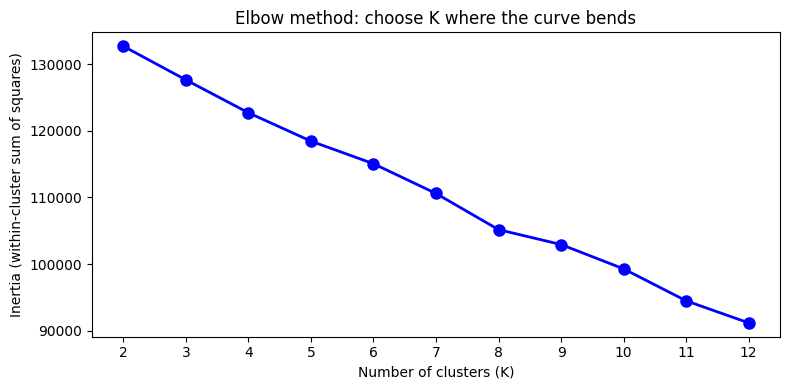

Suggested K from elbow (max curvature): 8. Use this for K-Means below.


In [129]:
K_RANGE = range(2, 13)
inertias = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_RANGE, inertias, "bo-", linewidth=2, markersize=8)
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow method: choose K where the curve bends")
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

# Elbow: k where the marginal drop in inertia levels off (second difference most negative)
d1 = -np.diff(inertias)  # drop in inertia when increasing k
d2 = np.diff(d1)         # when d2 < 0 the drop is slowing (curve flattens)
elbow_idx = np.argmin(d2) + 1 if len(d2) > 0 else 2
optimal_k = list(K_RANGE)[min(elbow_idx, len(list(K_RANGE)) - 1)]
print(f"Suggested K from elbow (max curvature): {optimal_k}. Use this for K-Means below.")

In [130]:
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
embed_arr = tsne.fit_transform(X_scaled)
df["tsne_1"] = embed_arr[:, 0]
df["tsne_2"] = embed_arr[:, 1]
print("t-SNE done. Columns tsne_1, tsne_2 added.")

t-SNE done. Columns tsne_1, tsne_2 added.


## 7. K-Means clustering

**What we do:** Partition households into **K** groups using the same `X_scaled` as for t-SNE. K comes from the elbow (or set by hand below).

**Why:** So "similar" for clusters is the same as in the t-SNE plot—both use the research columns only.

**What K-Means does:** Assigns each household to the cluster whose **center** (mean on all selected features) is closest. Households in the same cluster are similar on income, assets, housing, vulnerability, debt, etc., as defined by your column selection.

**Output:** A column `cluster` in `df` with values 0, 1, …, K−1. Use crosstabs (cluster vs region, vs area type) and cluster means to interpret and label types (e.g. "low income, rural").

In [131]:
n_clusters = optimal_k  # from elbow method above (or set manually if you prefer)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
print(f"Clustering: {n_clusters} clusters")

Clustering: 8 clusters


## 8. Plots: t-SNE colored by region, area type, and cluster

**What you see:** Each point = one household. X and Y = `tsne_1` and `tsne_2` (only relative distances matter; axes have no simple label).

- **By region:** Which marzes concentrate where on the socioeconomic map (e.g. Yerevan in one cloud, regions in another).
- **By area type:** Whether Yerevan / other urban / rural separate in the 2D space.
- **By cluster:** How the 6 socioeconomic types (from K-Means) look in the t-SNE map. Tight blobs = coherent types; overlapping = similar types.

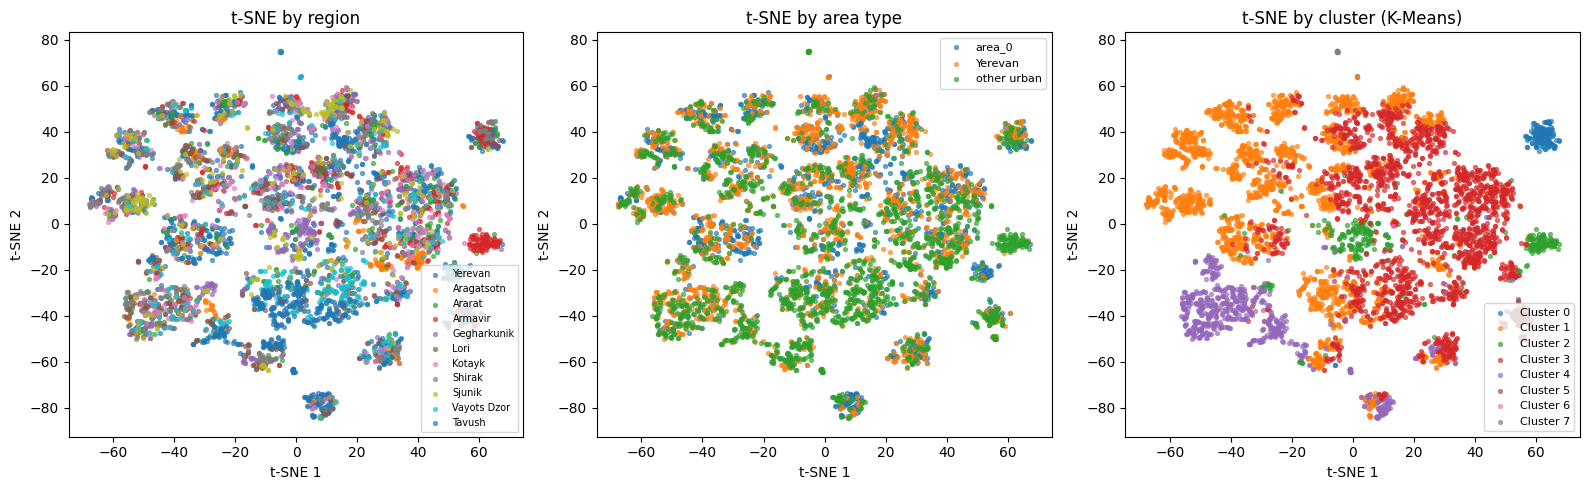

In [132]:
# Ensure region/area labels exist (e.g. if section 3 was skipped)
if "region_label" not in df.columns:
    def _value_label_map(var):
        sub = codebook[codebook["variable"] == var].copy()
        sub = sub[sub["value"].notna()]
        sub["value_num"] = pd.to_numeric(sub["value"], errors="coerce")
        sub = sub.dropna(subset=["value_num"])
        sub["value_num"] = sub["value_num"].astype(int)
        return dict(zip(sub["value_num"], sub["value_label"].astype(str)))
    _region_map = _value_label_map("marz")
    _area_map = _value_label_map("typev")
    df["region_label"] = df["region"].map(lambda x: _region_map.get(int(x), f"region_{x}") if pd.notna(x) else "Unknown")
    df["area_type_label"] = df["area_type"].map(lambda x: _area_map.get(int(x), f"area_{x}") if pd.notna(x) else "Unknown")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By region
ax = axes[0]
for label in df["region_label"].dropna().unique():
    mask = df["region_label"] == label
    ax.scatter(df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"], label=label, alpha=0.6, s=8)
ax.set_title("t-SNE by region")
ax.legend(loc="best", fontsize=7)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# By area type
ax = axes[1]
for label in df["area_type_label"].dropna().unique():
    mask = df["area_type_label"] == label
    ax.scatter(df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"], label=label, alpha=0.6, s=8)
ax.set_title("t-SNE by area type")
ax.legend(loc="best", fontsize=8)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# By cluster
ax = axes[2]
for c in sorted(df["cluster"].unique()):
    mask = df["cluster"] == c
    ax.scatter(df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"], label=f"Cluster {c}", alpha=0.6, s=8)
ax.set_title("t-SNE by cluster (K-Means)")
ax.legend(loc="best", fontsize=8)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

## 9. Crosstab: cluster vs. region and area type

**What the tables are:** Each cell = number of households in that **cluster** (row) and that **region** or **area type** (column). So we see *where* each socioeconomic type lives.

**How to use them:** Identify clusters that are mostly Yerevan vs. mostly other regions; mostly urban vs. rural. Combine with **per-cluster summary statistics** (e.g. mean income, share with poverty benefit) to name the segments (e.g. "better-off urban," "poor regional") and report your findings.

In [133]:
# Ensure region/area labels exist (e.g. if section 3 was skipped)
if "region_label" not in df.columns:
    def _value_label_map(var):
        sub = codebook[codebook["variable"] == var].copy()
        sub = sub[sub["value"].notna()]
        sub["value_num"] = pd.to_numeric(sub["value"], errors="coerce")
        sub = sub.dropna(subset=["value_num"])
        sub["value_num"] = sub["value_num"].astype(int)
        return dict(zip(sub["value_num"], sub["value_label"].astype(str)))
    _region_map = _value_label_map("marz")
    _area_map = _value_label_map("typev")
    df["region_label"] = df["region"].map(lambda x: _region_map.get(int(x), f"region_{x}") if pd.notna(x) else "Unknown")
    df["area_type_label"] = df["area_type"].map(lambda x: _area_map.get(int(x), f"area_{x}") if pd.notna(x) else "Unknown")

print("Cluster vs region (counts):")
print(pd.crosstab(df["cluster"], df["region_label"]))
print("\nCluster vs area type (counts):")
print(pd.crosstab(df["cluster"], df["area_type_label"]))

Cluster vs region (counts):
region_label  Aragatsotn  Ararat  Armavir  Gegharkunik  Kotayk  Lori  Shirak  \
cluster                                                                        
0                      0      10       30            1       0     8      21   
1                    140     158      157          113     117   228     178   
2                      2      20       97           85       0     1       0   
3                    110     198      139           71     166   124     140   
4                     41      43        9           38      40   156      85   
5                     31       1        0           14       0    23       7   
6                      0       0        0            0       0     0       0   
7                      0       2        0            2       1     0       1   

region_label  Sjunik  Tavush  Vayots Dzor  Yerevan  
cluster                                             
0                  2       6            1       56  
1           